# 09: GeoPandas - DataFrames with geometry for GIS applications


In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gp
from pathlib import Path
from shapely.geometry import Point, Polygon

In [2]:
datapath = Path('data/geopandas/')


**[Nice overview tutorial](https://geopandas.org/en/stable/getting_started/introduction.html)**
**[Examples Gallery](https://geopandas.org/en/stable/gallery/index.html)**

### OVERVIEW
***
In this notebook we will explore how `geopandas` works with GIS data (e.g. shapefiles and the objects within them) using geometrically-aware DataFrames. We will also explore how common GIS-related operations are available in `geopandas`. This notebook relies on publicly available GIS datasets for the city of Madison, Wisconsin.

#### get some data - `read_file` is the ticket for GeoJSON, shapefiles, GDB, etc.

In [3]:
parks = gp.read_file(datapath / 'Madison_Parks.geojson')

### writing back out is veeeery similar with `to_file` but give a few options for formats

In [4]:
parks.to_file(datapath / "parks.shp")

/tmp/ipykernel_6053/3998401397.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  parks.to_file(datapath / "parks.shp")
/home/runner/micromamba/envs/pyclass-docs/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'SHAPESTArea' to 'SHAPESTAre'
  ogr_write(
/home/runner/micromamba/envs/pyclass-docs/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'SHAPESTLength' to 'SHAPESTLen'
  ogr_write(


In [5]:
# or with a different driver
parks.to_file(datapath / "parks.json", driver='GeoJSON')

### this now looks like a Pandas DataFrame but there's a special column `geometry`

In [6]:
parks.head()

,OBJECTID,Park_ID,Type,Acreage,Park_Name,ShortName,Subtype,SHAPESTArea,SHAPESTLength,geometry
0,6416,3120,MINI,7.72,Quarry Cove Park,Quarry Cove,NaN,3.363779e+05,2808.992197,"POLYGON ((-89.48419 43.00851, -89.48416 43.010..."
1,6417,2610,MINI,2.36,Sunridge Park,Sunridge,NaN,1.027629e+05,1284.462030,"POLYGON ((-89.48162 43.04065, -89.4816 43.0410..."
2,6418,3320,MINI,1.09,Lederberg Park,Lederberg,NaN,4.752503e+04,940.774563,"POLYGON ((-89.53472 43.05151, -89.53511 43.052..."
3,6419,3020,MINI,3.22,Village Park,Village,NaN,1.402491e+05,1779.319445,"POLYGON ((-89.28712 43.16125, -89.28711 43.161..."
4,6420,1500,COMMUNITY,51.02,Olin Park,Olin,NaN,2.222246e+06,12658.852710,"MULTIPOLYGON (((-89.3763 43.05509, -89.37636 4..."


### also some important metadata particularly the [CRS](https://en.wikipedia.org/wiki/Spatial_reference_system)

In [7]:
parks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

> ### pro tip: You can have multiple geometry columns but only one is _active_ -- this is important later as we do operations on GeoDataFrames. The column labeled `geometry` is typically the active one but you [you can change it](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.set_geometry.html).

### So what's up with these geometries? They are represented as [`shapely`](https://shapely.readthedocs.io/en/stable/manual.html) objects so can be:
- #### polygon / multi-polygon
- #### point / multi-point
- #### line / multi-line

### we can access with pandas `loc` and `iloc` references

In [8]:
parks.iloc[1].geometry.geom_type

'Polygon'

In [9]:
parks.loc[parks.ShortName=='Olin'].geometry.geom_type

4    MultiPolygon
dtype: str

### There are other cool shapely properties like `area`

In [10]:
parks.loc[parks.ShortName=='Olin'].geometry.area

/tmp/ipykernel_6053/2331563363.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  parks.loc[parks.ShortName=='Olin'].geometry.area


4    0.000023
dtype: float64

### ruh-roh - what's up with this CRS and tiny area number?

In [11]:
parks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### area units in lat/long don't make sense. Let's project to something in meters (but how?) `to_crs` will do it, but importantly, either reassign or set `inplace=True`

In [12]:
parks.to_crs(3071, inplace=True)
parks.crs

<Projected CRS: EPSG:3071>
Name: NAD83(HARN) / Wisconsin Transverse Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Wisconsin.
- bounds: (-92.89, 42.48, -86.25, 47.31)
Coordinate Operation:
- name: Wisconsin Transverse Mercator 83
- method: Transverse Mercator
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [13]:
parks.loc[parks.ShortName=='Olin'].geometry.area

4    206286.146769
dtype: float64

### there are loads of useful methods for `shapely` objects for relationships between geometries (intersection, distance, etc.) but we will skip these for now because GeoPandas facilitates these things for entire geodataframes! #sick

> ### Pro Tip: There are occasions when, while connected to VPN, the first geometry in a GeoGataDrame has its CRS set to infinity rather than a target CRS. There are a couple potential fixes for that [here](https://gist.github.com/kallejahn/186496059f0d4bb0e9d6e6460c32055e)

## VISUALIZATION
***

### So back to GeoDataFrames.....we can look at them spatially as well with `plot()`

<Axes: >

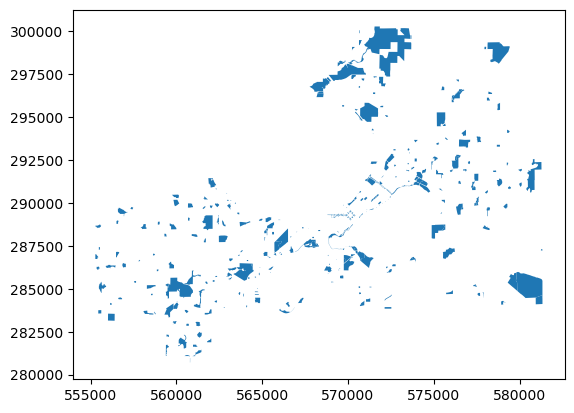

In [14]:
parks.plot()

### easily make a chloropleth map using a selected column as the color (and add a legend) using `plot()`

In [15]:
parks.columns

Index(['OBJECTID', 'Park_ID', 'Type', 'Acreage', 'Park_Name', 'ShortName',
       'Subtype', 'SHAPESTArea', 'SHAPESTLength', 'geometry'],
      dtype='str')

In [16]:
parks.sample(4)

,OBJECTID,Park_ID,Type,Acreage,Park_Name,ShortName,Subtype,SHAPESTArea,SHAPESTLength,geometry
75,6492,1350,MINI,0.100000,Hampton Court Park,Hampton Ct,NaN,4.546077e+03,284.960331,"POLYGON ((562699.688 289013, 562679.278 289012..."
114,6531,2940,NEIGHBORHOOD,28.709999,Blackhawk Park,Blackhawk,NaN,1.250485e+06,6354.032803,"POLYGON ((556595.349 289634.554, 556595.519 28..."
177,6595,2020,MINI,1.600000,Esther Beach Park,Esther,NaN,6.978328e+04,1113.207140,"POLYGON ((572251.465 286200.031, 572251.55 286..."
251,6671,1910,COMMUNITY,20.120001,Rennebohm Park,Rennebohm,NaN,8.764421e+05,5322.101300,"POLYGON ((563712.106 288638.585, 563712.245 28..."


<Axes: >

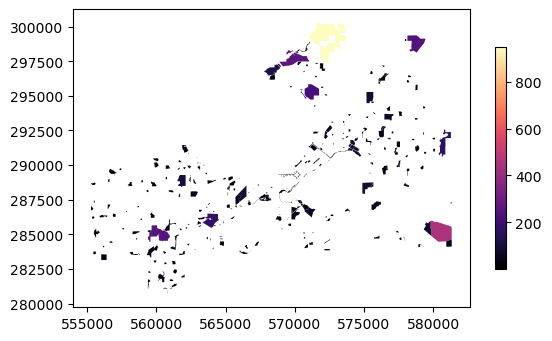

In [17]:
parks.plot(column="Acreage", cmap = 'magma', k=5, legend=True, legend_kwds={'shrink': 0.6})

### also a very cool interactive plot options with a basemap using `explore()`

In [18]:
parks.explore(column='Acreage', cmap='magma')

### we can read in another shapefile

In [19]:
hoods = gp.read_file(datapath / 'Neighborhood_Associations.geojson')

In [20]:
hoods.sample(5)

,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength,geometry
29,9876,35,Hiestand Neighborhood Association,Inactive,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.860710e+07,20784.240494,"POLYGON ((-89.30468 43.09875, -89.30328 43.098..."
6,9853,8,Bram's Addition Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,5.606445e+06,11582.094982,"POLYGON ((-89.38929 43.04924, -89.38929 43.049..."
130,9977,169,Madison West Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.179120e+08,122060.125747,"POLYGON ((-89.50317 43.04736, -89.50317 43.047..."
90,9937,126,Park Ridge Neighborhood Association,Inactive,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.319349e+06,4997.382801,"POLYGON ((-89.50231 43.0404, -89.50221 43.0404..."
87,9934,117,Country Grove Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,5.702869e+06,9909.433559,"POLYGON ((-89.50763 43.00899, -89.50761 43.009..."


### and we can plot these on top of each other

<Axes: >

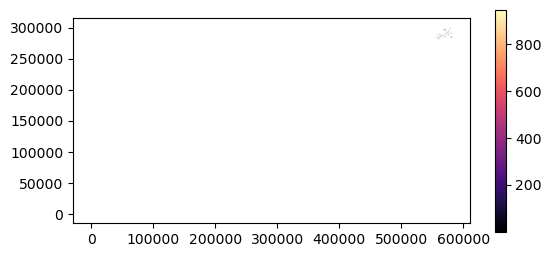

In [21]:
ax_hood = hoods.plot()
# now plot the other one but specify which axis to plot on (ax=ax_hood)
parks.plot(column="Acreage", cmap = 'magma', k=5, legend=True, legend_kwds={'shrink': 0.6}, ax=ax_hood)

### WAT! Why so far apart?

In [22]:
hoods.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### we need to reproject. Geopandas uses `to_crs()` for this purpose

In [23]:
# we can reproject, and set hoods to park crs 
hoods.to_crs(parks.crs, inplace=True)

<Axes: >

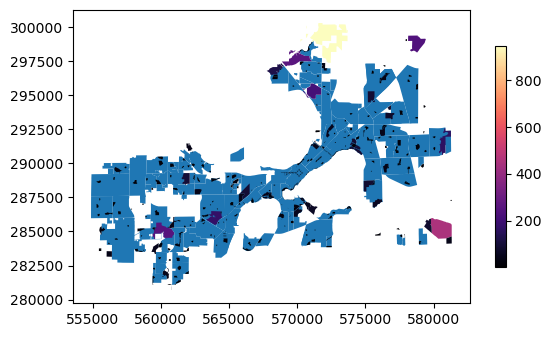

In [24]:
ax_hood = hoods.plot()
# now plot the other one but specify which axis to plot on (ax=ax_hood)
parks.plot(column="Acreage", cmap = 'magma', k=5, legend=True, legend_kwds={'shrink': 0.6}, ax=ax_hood)

### or similarly with the interactive maps

In [25]:
m_hood = hoods.explore()
parks.explore(column="Acreage", cmap = 'magma', k=5, legend=True, legend_kwds={'shrink': 0.6}, m=m_hood)

### we can make a new geodataframe using shapely properties of the geometry - how about centroids?

## TEST YOUR SKILLS #0
- make a new geodataframe of the parks
- add a columns with centroids for each park
- plot an interactive window with the park centroids and the neighborhoods
- hints: 
    - remember the shapely methods are available for each geometry object (e.g. `centroid()`) 
    - you can loop over the column in a couple different ways
    - you can define which columns contains the geometry of a geodataframe
    - you will likely have to define the CRS

## GEOSPATIAL OPERATIONS
***

### Operations on and among geodataframes...do I need to use a GIS program?

### Dissolve

In [26]:
hoods.dissolve() # note it defaults to filling all the columns with the first value

,geometry,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength
0,"MULTIPOLYGON (((560429.904 281602.442, 560430....",9847,1,Allied Dunn's Marsh Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.512568e+07,16657.055614


<Axes: >

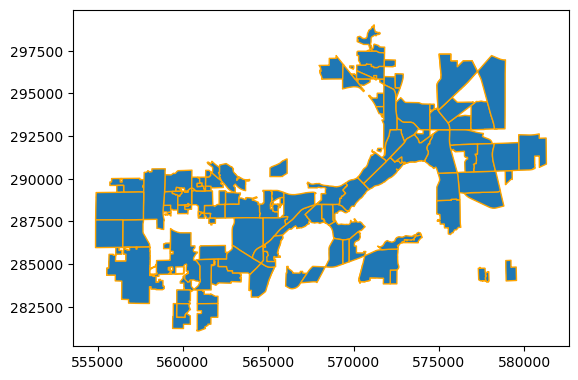

In [27]:
ax=hoods.dissolve().plot()
hoods.plot(facecolor=None, edgecolor='orange', ax=ax)

### Convex Hull

<Axes: >

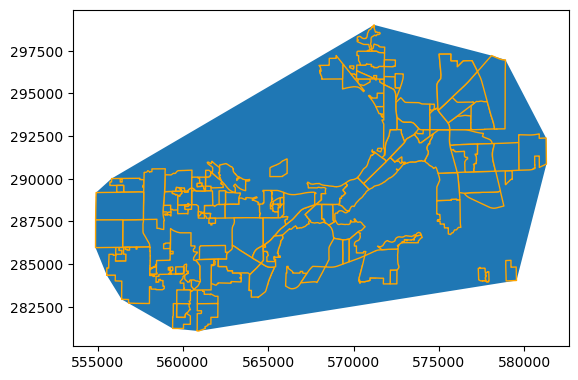

In [28]:
ax = hoods.dissolve().convex_hull.plot()
hoods.plot(facecolor=None, edgecolor='orange', ax=ax)

### Bounding Box is a little more tricky

In [29]:
hoods.bounds # that's per each row

,minx,miny,maxx,maxy
0,563872.429544,283460.518859,565328.837226,285057.462675
1,561310.621737,289288.751579,561646.281647,289570.375291
2,566010.016502,283558.607236,567270.271941,284869.636703
3,568527.624082,286423.950486,570669.728818,287657.510073
4,569018.771979,288242.314399,569250.882412,288506.627088
...,...,...,...,...
135,574180.047766,290323.744701,576068.029053,292858.768636
136,572143.872431,290896.914666,574663.138190,292637.318811
137,554878.971311,287588.991000,557696.123932,289229.663701
138,567269.204147,288485.712034,569627.785405,289802.439174


In [30]:
tb = hoods.total_bounds # this gives overall bounds
tb

array([554873.11459994, 281085.59466762, 581291.42545321, 299016.88496873])

### We can make a polygon from these coordinates with `shapely`

In [31]:
from shapely.geometry import box

In [32]:
bbox = box(tb[0], tb[1], tb[2], tb[3])
# pro tip - when passing a bunch of ordered arguments, '*' will unpack them #nice
bbox = box(*hoods.total_bounds)

#### to make a GeoDataFrame from scratch, the minimum you need is geometry, but a crs is important, and some data will populate more columns

In [33]:
hoods_boundary = gp.GeoDataFrame(data={'thing':['bounding_box']},geometry=[bbox], crs=hoods.crs)
hoods_boundary

,thing,geometry
0,bounding_box,"POLYGON ((581291.425 281085.595, 581291.425 29..."


<Axes: >

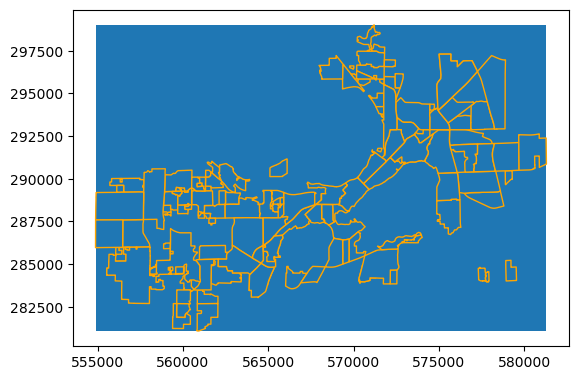

In [34]:
ax = hoods_boundary.plot()
hoods.plot(facecolor=None, edgecolor='orange', ax=ax)

## How about some spatial joins?
***

#### we can bring in information based on locational overlap. Let's look at just a couple neighborhoods (Marquette and Tenny-Lapham) on the Isthmus

In [35]:
isthmus = hoods.loc[hoods['NEIGHB_NAME'].str.contains('Marquette') | 
                   hoods['NEIGHB_NAME'].str.contains('Tenney')]
isthmus

,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength,geometry
40,9887,49,Marquette Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.973684e+07,23274.760528,"POLYGON ((572818.456 291044.343, 572821.978 29..."
68,9915,92,Tenney-Lapham Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.333260e+07,18614.467212,"POLYGON ((571192.747 291561.285, 571106.236 29..."


In [36]:
isthmus.explore()

In [37]:
isthmus.sjoin(parks).explore()

In [38]:
parks.sjoin(isthmus).explore()

#### so, it matters which direction you join from. The geometry is preserved from the dataframe "on the left"
#### equivalently, you can be more explicit in calling `sjoin`

In [39]:
gp.sjoin(left_df=parks, right_df=isthmus).explore()

In [40]:
isthmus_parks = gp.sjoin(left_df=parks, right_df=isthmus)

#### we are going to use this `isthmus_parks` geoDataFrame a little later, but we want to trim out some unneeded and distracting columns. We can use `.drop()` just like with a regular Pandas DataFrame

In [41]:
isthmus_parks.columns

Index(['OBJECTID_left', 'Park_ID', 'Type', 'Acreage', 'Park_Name', 'ShortName',
       'Subtype', 'SHAPESTArea', 'SHAPESTLength', 'geometry', 'index_right',
       'OBJECTID_right', 'NA_ID', 'NEIGHB_NAME', 'STATUS', 'CLASSIFICA', 'Web',
       'ShapeSTArea', 'ShapeSTLength'],
      dtype='str')

In [42]:
isthmus_parks.drop(columns=[ 'index_right','OBJECTID_right', 'NA_ID', 
       'STATUS', 'CLASSIFICA', 'Web',
       'ShapeSTArea', 'ShapeSTLength'], inplace=True)

### Let's explore the various predicates with a small intersecting box

<Axes: >

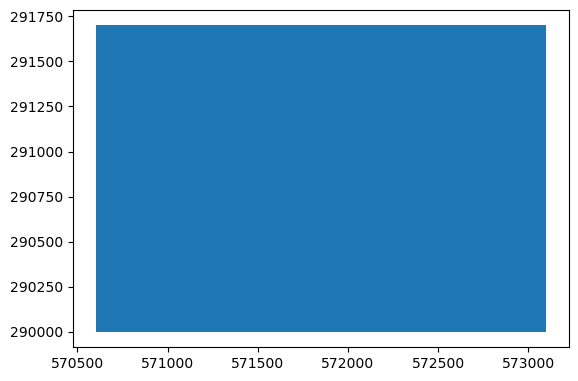

In [43]:
bbox = box(570600, 290000, 573100, 291700)
bounds = gp.GeoDataFrame(geometry=[bbox],crs=parks.crs)
bounds.plot()

#### See [documentation](https://shapely.readthedocs.io/en/latest/manual.html#binary-predicates) for full set of options for predicates. We'll just check out a couple options: `intersects`, `contains`, `within`

## TEST YOUR SKILLS #1
***
Using the `bounds` geodataframe you just made, write a function to visualize predicate behaviors.
- your function should accept a left geodataframe, a right geodataframe, and a string for the predicate
- your function should plot:
    - the left geodataframe in (default) blue
    - the result of the spatial join operation in another color
    - the right geodataframe in another color with outline only
- then you should set the title of the plot to the string predicate value used
- the geodataframes to test with are `isthmus_parks` and `bounds`
- your function should `return` the joined geodataframe

- a couple hints:
    - in the `plot` method are a couple args called `facecolor` and `edgecolor` that will help plot the rectangle
    - there are other predicates to try out 

- _advanced options_: if that was easy, you can try a couple other things like:
    - explore joins with points and lines in addition to just polygons
    - change around the `bounds` polygon dimensions 
    - use `explore()` to make an interactive map

#### Spatial joins are particularly useful with collections of points. A common case is to add a polygon attribute to points falling within each polygon. Let's check out a bigger point dataset with all the trees on streets in Madison

<Axes: >

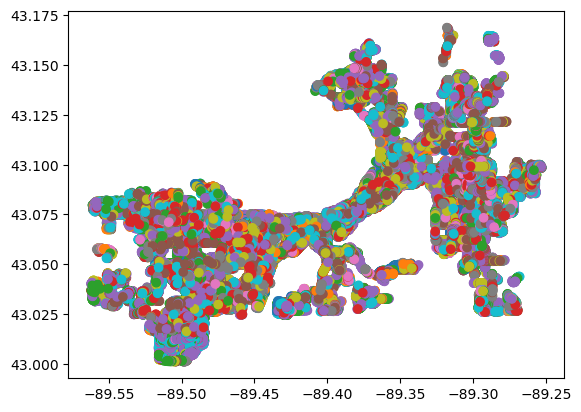

In [44]:
trees = gp.read_file(datapath / 'Street_Trees.geojson')
trees.plot(column='SPECIES')

#### let's put this into the same crs as neighborhoods and join the data together so we can have a neighborhood attribute on the trees geodataframe

In [45]:
trees.to_crs(hoods.crs, inplace=True)

In [46]:
hoods.columns

Index(['OBJECTID', 'NA_ID', 'NEIGHB_NAME', 'STATUS', 'CLASSIFICA', 'Web',
       'ShapeSTArea', 'ShapeSTLength', 'geometry'],
      dtype='str')

#### NOTE: if we pass only some columns of the GeoDataFrame, only those columns will be included in the result, which is cool. _But_ - must include the active geometry column as well!

In [47]:
trees_with_hoods = trees[['SPECIES','DIAMETER','geometry']].sjoin(hoods[['NEIGHB_NAME','geometry']])
trees_with_hoods

,SPECIES,DIAMETER,geometry,index_right,NEIGHB_NAME
0,554,22.0,POINT (569406.122 285635.225),6,Bram's Addition Neighborhood Association
1,554,20.0,POINT (569391.615 285635.545),6,Bram's Addition Neighborhood Association
2,320,14.0,POINT (569383.333 285772.643),6,Bram's Addition Neighborhood Association
3,320,20.0,POINT (569407.725 285782.686),6,Bram's Addition Neighborhood Association
4,320,20.0,POINT (569431.459 285792.707),6,Bram's Addition Neighborhood Association
...,...,...,...,...,...
112506,462,2.0,POINT (560220.817 289224.439),79,Wexford Village Condominium Owners Assoc
112507,804,2.0,POINT (560124.192 289029.458),73,Walnut Grove Homeowners Association
112508,734,2.0,POINT (559632.848 288907.214),58,Sauk Creek Neighborhood Association
112509,804,2.0,POINT (559630.291 288945.507),58,Sauk Creek Neighborhood Association


#### now we can do a `groupby`, for example, to find things like the average or max diameter of trees in each neighborhood

<Axes: xlabel='NEIGHB_NAME'>

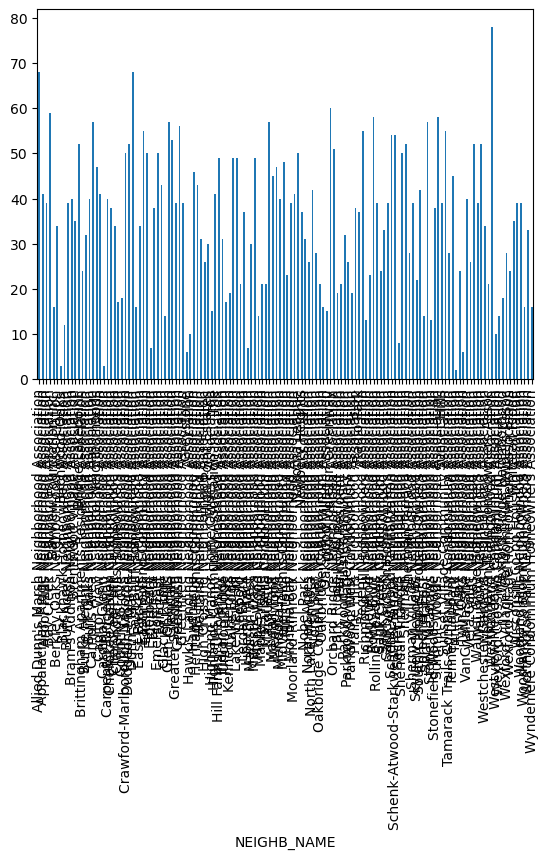

In [48]:
trees_with_hoods.groupby('NEIGHB_NAME')['DIAMETER'].max().plot(kind='bar')

#### We could rearrange that bar chart in various ways, but we can also flip this back to the original neighborhoods GeoDataFrame to make a more useful spatial plot. Note that we used the spatial join to join together the attribute "Neighborhood Name" with each tree point. But now, we can aggregate those results and assign them based on an attribute rather than geospatially just like regular Pandas DataFrames

In [49]:
hood_trees = hoods.copy()
tree_summary = trees_with_hoods.groupby('NEIGHB_NAME')['DIAMETER'].max()
hood_trees.merge(tree_summary,
                left_on = 'NEIGHB_NAME', right_on='NEIGHB_NAME').explore(column="DIAMETER")

## Overlays
***
### As we've seen, spatial joins are powerful, but they really only gather data from multiple collections. What if we want to actually calculate the amount of overlap among shapes? Or create new shapes based on intersection or not intersection of shapes?

### [overlay](https://geopandas.org/en/stable/docs/user_guide/set_operations.html?highlight=overlay) does these things.

#### main options are `intersection`, `difference`, `union`, and `symmetric_difference`

<Axes: >

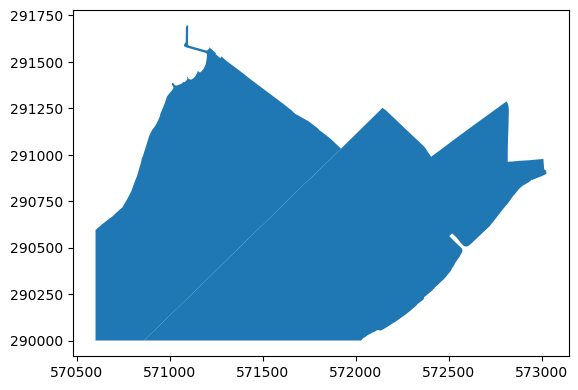

In [50]:
inters = bounds.overlay(isthmus, how='intersection')
inters.plot()

<Axes: >

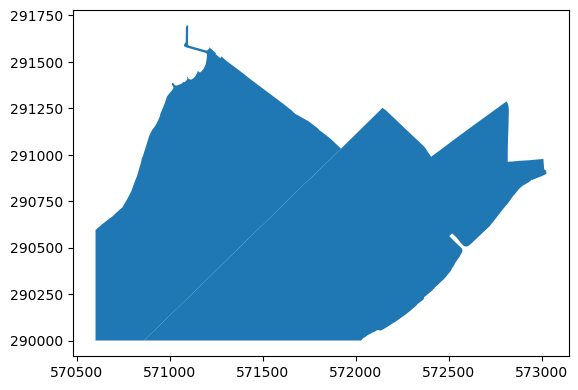

In [51]:
inters = bounds.overlay(isthmus, how='intersection')
inters.plot()

In [52]:
inters

,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength,geometry
0,9887,49,Marquette Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.973684e+07,23274.760528,"POLYGON ((570860.48 290000, 570864.33 290003.7..."
1,9915,92,Tenney-Lapham Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.333260e+07,18614.467212,"POLYGON ((570600 290000, 570600 290594.312, 57..."


<Axes: >

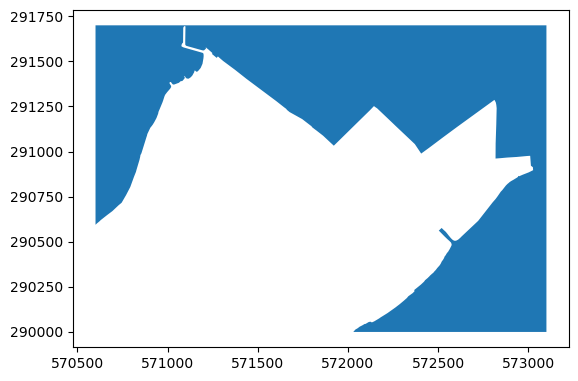

In [53]:
differ = bounds.overlay(isthmus, how='difference')
differ.plot()

In [54]:
differ

,geometry
0,"POLYGON ((570600 291700, 573100 291700, 573100..."


<Axes: >

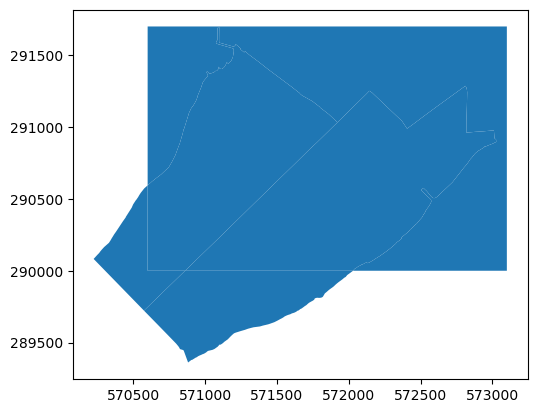

In [55]:
unite = bounds.overlay(isthmus, how='union')
unite.plot()

In [56]:
unite

,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength,geometry
0,9887.0,49.0,Marquette Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.973684e+07,23274.760528,"POLYGON ((570860.48 290000, 570864.33 290003.7..."
1,9915.0,92.0,Tenney-Lapham Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.333260e+07,18614.467212,"POLYGON ((570600 290000, 570600 290594.312, 57..."
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((570600 291700, 573100 291700, 573100..."
3,9887.0,49.0,Marquette Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.973684e+07,23274.760528,"POLYGON ((572028.3 289999.01, 572016.817 28999..."
4,9915.0,92.0,Tenney-Lapham Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.333260e+07,18614.467212,"POLYGON ((570717.845 289861.621, 570574.454 28..."


<Axes: >

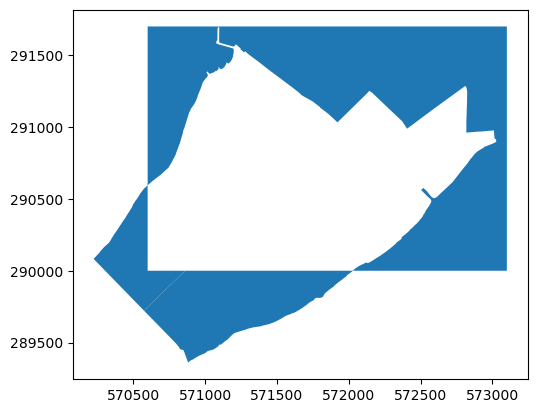

In [57]:
symdiff = bounds.overlay(isthmus, how='symmetric_difference')
symdiff.plot()

In [58]:
symdiff

,OBJECTID,NA_ID,NEIGHB_NAME,STATUS,CLASSIFICA,Web,ShapeSTArea,ShapeSTLength,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((570600 291700, 573100 291700, 573100..."
1,9887.0,49.0,Marquette Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.973684e+07,23274.760528,"POLYGON ((572028.3 289999.01, 572016.817 28999..."
2,9915.0,92.0,Tenney-Lapham Neighborhood Association,Active,Neighborhood Association,http://www.cityofmadison.com/neighborhoods/pro...,1.333260e+07,18614.467212,"POLYGON ((570717.845 289861.621, 570574.454 28..."


### On your own...
- what if you switch left and right dataframes?
- how can you evaluate the areas of overlap for the intersection case?

## TEST YOUR SKILLS _OPTIONAL_
***
We have an Excel file that contains a crosswalk between SPECIES number as provided and species name. Can we bring that into our dataset and evaluate some conclusions about tree species by neighborhood?
- start with the `trees_with_hoods` GeoDataFrame
- load up and join the data from datapath / 'Madison_Tree_Species_Lookup.xlsx'
- hint: check the dtypes before merging - if you are going to join on a column, the column must be the same dtype in both dataframes
- Make a multipage PDF with a page for each neighborhood showing a bar chart of the top ten tree species (by name) in each neighborhood
- Make a map (use explore, or save to SHP or geojson) showing the neighborhoods with a color-coded field showing the most common tree species for each neighborhood

You will need a few pandas operations that we have only touched on a bit:  

`groupby`, `count`, `merge`, `read_excel`, `sort_values`, `iloc`